# 最简单的 RL Demo：Q-learning

这个 notebook 用一个**一维走格子**的小环境，演示强化学习（RL）里智能体是怎么通过“试错 + 奖励”学会策略的。

我们会看到：
- 环境里有一个起点和一个终点
- 智能体每一步只能向左或向右
- 到达终点会得到奖励 `+1`
- 智能体通过不断尝试，慢慢学会更快走到终点


## 1. 先理解这个任务

环境是一条长度为 6 的线：

`A . . . . G`

- `A` 是智能体当前位置
- `G` 是目标位置
- 动作只有两个：`0 = left`，`1 = right`
- 到达终点 `G` 时奖励是 `+1`
- 其他时候奖励是 `0`

这个任务非常简单，但它已经具备 RL 的核心要素：
- `state`：当前位置
- `action`：向左/向右
- `reward`：到达目标才给奖励
- `policy`：在每个状态下应该采取什么动作


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)


In [3]:
class LineWorld:
    """
    一个最简单的一维环境。
    状态就是智能体所在的位置。
    """

    def __init__(self, length=6):
        self.length = length
        self.goal = length - 1
        self.reset()

    def reset(self):
        # 每一轮训练都从最左边开始
        self.position = 0
        return self.position

    def step(self, action):
        # action = 0 表示向左，action = 1 表示向右
        if action == 0:
            self.position = max(0, self.position - 1)
        else:
            self.position = min(self.goal, self.position + 1)

        # 只有到达终点时才给奖励
        reward = 1 if self.position == self.goal else 0
        done = self.position == self.goal
        return self.position, reward, done

    def render(self):
        cells = ['.'] * self.length
        cells[self.goal] = 'G'
        if self.position != self.goal:
            cells[self.position] = 'A'
        else:
            cells[self.position] = 'A/G'
        return ' '.join(cells)


## 2. Q-learning 的核心公式

Q-learning 维护一张 `Q 表`，含义是：

`Q(state, action)` = 在某个状态下采取某个动作，有多好。

更新公式是：

$Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s, a)]$

直观理解：
- 先看这一步拿到了多少奖励 `r`
- 再看下一状态 `s'` 的最好未来价值
- 用新的估计值，去修正旧的 Q 值

这里：
- `alpha`：学习率，控制每次更新幅度
- `gamma`：折扣因子，表示对未来奖励的重视程度
- `epsilon`：探索率，表示要不要随机试一试


In [4]:
# 环境配置
env = LineWorld(length=6)
n_states = env.length
n_actions = 2  # 0=left, 1=right

# Q 表初始化为 0
q_table = np.zeros((n_states, n_actions))

# 超参数
alpha = 0.1   # 学习率
gamma = 0.9   # 折扣因子
epsilon = 0.2 # 探索概率
episodes = 200
max_steps_per_episode = 30

episode_rewards = []
episode_steps = []
q_history = []

def choose_action(state, q_table, epsilon):
    # epsilon-greedy:
    # 以 epsilon 的概率随机探索
    # 以 1-epsilon 的概率选择当前最优动作
    if random.random() < epsilon:
        return random.randint(0, 1)
    best_actions = np.flatnonzero(q_table[state] == np.max(q_table[state]))
    return int(random.choice(best_actions))


In [5]:
for episode in range(episodes):
    state = env.reset()
    total_reward = 0

    for step in range(max_steps_per_episode):
        action = choose_action(state, q_table, epsilon)
        next_state, reward, done = env.step(action)

        # Q-learning 核心更新：
        # 当前估计 = q_table[state, action]
        # 目标值 = reward + gamma * 下一状态的最大 Q 值
        old_value = q_table[state, action]
        next_best = 0 if done else np.max(q_table[next_state])
        target = reward + gamma * next_best
        q_table[state, action] = old_value + alpha * (target - old_value)

        state = next_state
        total_reward += reward

        if done:
            episode_steps.append(step + 1)
            break
    else:
        # 如果一直没到终点，说明这一轮学得不好
        episode_steps.append(max_steps_per_episode)

    episode_rewards.append(total_reward)
    q_history.append(q_table.copy())

    # 训练后期适当减少探索，让智能体更偏向利用已有经验
    epsilon = max(0.02, epsilon * 0.995)

print('训练完成！')
print('最终 Q 表：')
print(q_table)


训练完成！
最终 Q 表：
[[0.431 0.656]
 [0.478 0.729]
 [0.164 0.81 ]
 [0.454 0.9  ]
 [0.583 1.   ]
 [0.    0.   ]]


In [7]:
# 看看学到的策略
action_map = {0: '←', 1: '→'}
policy = [action_map[int(np.argmax(q_table[s]))] for s in range(n_states - 1)] + ['G']
print('学到的策略：')
for s, a in enumerate(policy):
    print(f'状态 {s}: {a}')


学到的策略：
状态 0: →
状态 1: →
状态 2: →
状态 3: →
状态 4: →
状态 5: G


## 3. 可视化训练过程

下面我们画两条最关键的曲线：
- 每个 episode 走了多少步到终点
- 每个 episode 是否拿到奖励

如果学习有效，通常会看到：
- 后期步数下降
- 奖励更稳定地拿到


C:\Users\80740\AppData\Local\Temp\ipykernel_16844\2137847651.py:13: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16844\2137847651.py:13: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16844\2137847651.py:13: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16844\2137847651.py:13: UserWarning: Glyph 36798 (\N{CJK UNIFIED IDEOGRAPH-8FBE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16844\2137847651.py:13: UserWarning: Glyph 32456 (\N{CJK UNIFIED IDEOGRAPH-7EC8}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16844\2137847651.py:13: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9})

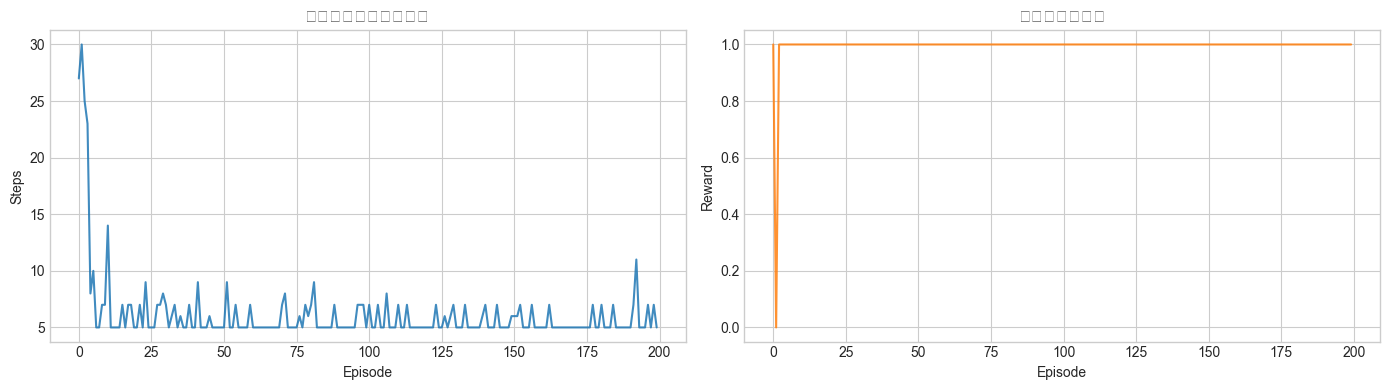

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(episode_steps, color='#1f77b4', alpha=0.85)
axes[0].set_title('每轮到达终点所需步数')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Steps')

axes[1].plot(episode_rewards, color='#ff7f0e', alpha=0.85)
axes[1].set_title('每轮获得的奖励')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Reward')

plt.tight_layout()
plt.show()


C:\Users\80740\AppData\Local\Temp\ipykernel_16844\3354344539.py:18: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16844\3354344539.py:18: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16844\3354344539.py:18: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16844\3354344539.py:18: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16844\3354344539.py:18: UserWarning: Glyph 28369 (\N{CJK UNIFIED IDEOGRAPH-6ED1}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16844\3354344539.py:18: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8})

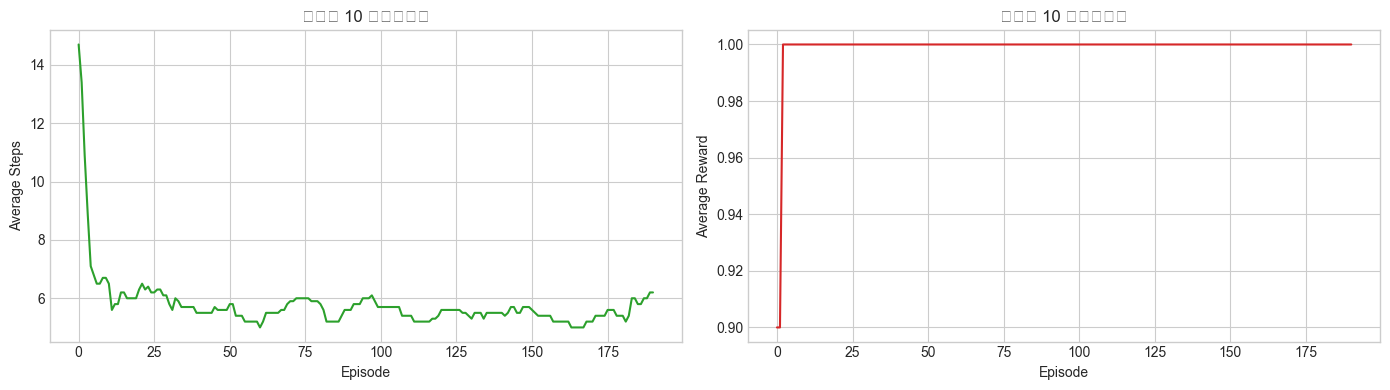

In [9]:
# 再做一个滑动平均，让趋势更清楚
window = 10
smoothed_steps = np.convolve(episode_steps, np.ones(window) / window, mode='valid')
smoothed_rewards = np.convolve(episode_rewards, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(smoothed_steps, color='#2ca02c')
axes[0].set_title(f'步数的 {window} 轮滑动平均')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Average Steps')

axes[1].plot(smoothed_rewards, color='#d62728')
axes[1].set_title(f'奖励的 {window} 轮滑动平均')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Average Reward')

plt.tight_layout()
plt.show()


## 4. 动画式看智能体怎么走

下面用训练好的 Q 表，让智能体从起点出发，按学到的策略一步步移动。


In [10]:
demo_env = LineWorld(length=6)
state = demo_env.reset()

for t in range(10):
    clear_output(wait=True)
    print(f'第 {t + 1} 步: {demo_env.render()}')

    action = int(np.argmax(q_table[state]))
    state, reward, done = demo_env.step(action)

    if done:
        clear_output(wait=True)
        print(f'第 {t + 1} 步: {demo_env.render()}')
        print('智能体成功到达目标！')
        break


第 5 步: . . . . . A/G
智能体成功到达目标！


## 5. 你应该从这个 demo 记住什么

1. 强化学习不是直接看答案，而是通过和环境交互来学习。
2. 奖励设计非常关键，因为它决定了智能体会偏向学什么。
3. Q-learning 的本质，是不断更新“某个状态下做某个动作到底值不值”。
4. 探索（exploration）和利用（exploitation）之间要平衡。
5. 这个例子很小，但思想可以扩展到游戏、机器人、推荐系统等任务。

如果你下一步要准备面试，可以继续往下学：
- Bellman Equation
- SARSA vs Q-learning
- DQN 为什么需要神经网络
- Policy-based / Actor-Critic 的区别
